In [37]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, monotonically_increasing_id
import pandas as pd
import numpy as np
import math
import mlflow
import mlflow.sklearn
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, make_scorer, average_precision_score
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
from IPython.display import display
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
except:
    !pip install shap
    import shap
try:
    from catboost import CatBoostClassifier, Pool
except:
    !pip install catboost
    from catboost import CatBoostClassifier, Pool

try:
    from lightgbm import LGBMClassifier
except:
    !pip install lightgbm
    from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
except:
    !pip install xgboost
    from xgboost import XGBClassifier
try:
    import phik
except:
    !pip install phik
    import phik


import warnings
warnings.filterwarnings("ignore")

In [2]:
import logging
import io

log_stream = io.StringIO()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.StreamHandler(log_stream)
    ]
)

logger = logging.getLogger("model_training")


In [3]:
spark = SparkSession.builder \
    .appName("TreesProject") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://hadoop:8020") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/13 00:22:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
def gini_score(y_true, y_pred):
    roc_auc = roc_auc_score(y_true, y_pred)
    return 2 * roc_auc - 1

gini_scorer = make_scorer(gini_score, greater_is_better=True, needs_proba=True)

In [5]:
mlflow.set_experiment("TreesProject")

<Experiment: artifact_location='s3://mlops-check/mlflow/862663795257231460', creation_time=1744490739556, experiment_id='862663795257231460', last_update_time=1744490739556, lifecycle_stage='active', name='TreesProject', tags={}>

In [6]:
def load_hdfs_data(path: str):
    return spark.read.parquet(
        f"hdfs://hadoop:8020{path}",
        header = False,
        inferSchema = True,
        
    )

In [7]:
def simple_spark_stat(X, y):
    print("Size X: ", X.count(), len(X.columns))
    print("Missing: ")
    X.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in X.columns]).show()

    print("Balance classes: ")
    y.groupBy(columns_meta['target_col']).count().show()

    print("Stat: ")
    X.describe().show(10)

In [8]:
def dataframe_EDA(df, y, limit_size=0.1, seed=42, columns_dict=None, scale_coef=1.1):
    target_col = columns_dict["target_col"]
    df_indexed = df.withColumn("idx", monotonically_increasing_id())
    y_indexed = y.withColumn("idx", monotonically_increasing_id())
    df_full = df_indexed.join(y_indexed, on="idx").drop("idx")
    df_pd = df_full.sample(False, limit_size, seed).toPandas()
    y_pd = df_pd[target_col]
    df_pd = df_pd.drop([target_col], axis = 1)
    
    if 'target' not in df_pd.columns and len(y_pd) == len(df_pd):
        df_pd['target'] = y_pd
    
    print("Numeric cols:")
    for col in columns_dict['numeric_cols']:
        if col == columns_dict.get('target_col', ''):
            continue
            
        print("\n" + "="*50)
        print(f"Analysis for column: {col}")
        
        plt.figure(figsize=(10, 5))
        df_pd[col].hist(bins=math.ceil(np.log(len(df_pd[col].unique())) + 1))
        plt.xlim(df_pd[col].min(), df_pd[col].max() * scale_coef)
        plt.title(f"Frequency of values for {col}")
        plt.ylabel('Frequency')
        plt.xlabel('Value')
        plt.show()
        
        plt.figure(figsize=(10, 5))
        plt.boxplot(df_pd[col].dropna())
        plt.title(f"Boxplot for {col}")
        plt.ylabel('Value')
        plt.show()
        
        print("Descriptive statistics:")
        display(df_pd[col].describe())
    
    print("\n" + "="*50)
    print("Categorical cols:")
    for col in columns_dict['categorial_cols']:
        print("\n" + "-"*50)
        print(f"Analysis for column: {col}")
        
        value_counts = df_pd[col].value_counts()
        
        plt.figure(figsize=(8, 8))
        plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
        plt.title(f"Distribution of {col}")
        plt.show()
        
        if len(value_counts) > 1:
            ratio = value_counts.max() / value_counts.min()
            print(f"Max to min group ratio: {ratio:.2f}")
        else:
            print("Only one category exists")
        
        display(value_counts.to_frame(name='Count'))
    
    print("\n" + "="*50)
    print("Target classes balance:")
    target_col = columns_dict.get('target_col', 'target')
    if target_col in df_pd.columns:
        target_counts = df_pd[target_col].value_counts()
    else:
        target_counts = y_pd.value_counts()
    
    display(target_counts.to_frame(name='Count'))
    
    if len(target_counts) > 1:
        imbalance_ratio = target_counts.max() / target_counts.min()
        print(f"Class imbalance ratio: {imbalance_ratio:.2f}")
    
    return df_pd
    

In [9]:
columns_meta = spark.read.json("hdfs://hadoop:8020/my_data/columns.json")
columns_meta = columns_meta.first().asDict()
columns_meta

{'categorial_cols': ['Education', 'City', 'Gender', 'EverBenched'],
 'numeric_cols': ['JoiningYear',
  'PaymentTier',
  'Age',
  'ExperienceInCurrentDomain',
  'LeaveOrNot'],
 'target_col': 'LeaveOrNot'}

In [10]:
X_train = load_hdfs_data("/my_data/X_train.csv")
X_test = load_hdfs_data("/my_data/X_test.csv")
y_train = load_hdfs_data("/my_data/y_train.csv")
y_test = load_hdfs_data("/my_data/y_test.csv")

In [11]:
simple_spark_stat(X_train, y_train)

Size X:  3489 8
Missing: 
+---------+-----------+----+-----------+---+------+-----------+-------------------------+
|Education|JoiningYear|City|PaymentTier|Age|Gender|EverBenched|ExperienceInCurrentDomain|
+---------+-----------+----+-----------+---+------+-----------+-------------------------+
|        0|          0|   0|          0|  0|     0|          0|                        0|
+---------+-----------+----+-----------+---+------+-----------+-------------------------+

Balance classes: 
+----------+-----+
|LeaveOrNot|count|
+----------+-----+
|         1| 1211|
|         0| 2278|
+----------+-----+

Stat: 


25/04/13 00:22:36 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+---------+------------------+---------+-----------------+------------------+------+-----------+-------------------------+
|summary|Education|       JoiningYear|     City|      PaymentTier|               Age|Gender|EverBenched|ExperienceInCurrentDomain|
+-------+---------+------------------+---------+-----------------+------------------+------+-----------+-------------------------+
|  count|     3489|              3489|     3489|             3489|              3489|  3489|       3489|                     3489|
|   mean|     null|2015.0779593006591|     null|2.692748638578389|29.439954141587847|  null|       null|       2.9077099455431354|
| stddev|     null|1.8682826975653948|     null|0.567321724755536| 4.858303871893741|  null|       null|       1.5596218999777356|
|    min|Bachelors|              2012|Bangalore|                1|                22|Female|         No|                        0|
|    max|      PHD|              2018|     Pune|                3|                4

In [12]:
y_train[y_train.columns[0]]

Column<'LeaveOrNot'>

In [13]:
columns_meta['target_col']

'LeaveOrNot'

## Распределения признаков


Numeric cols:

Analysis for column: JoiningYear


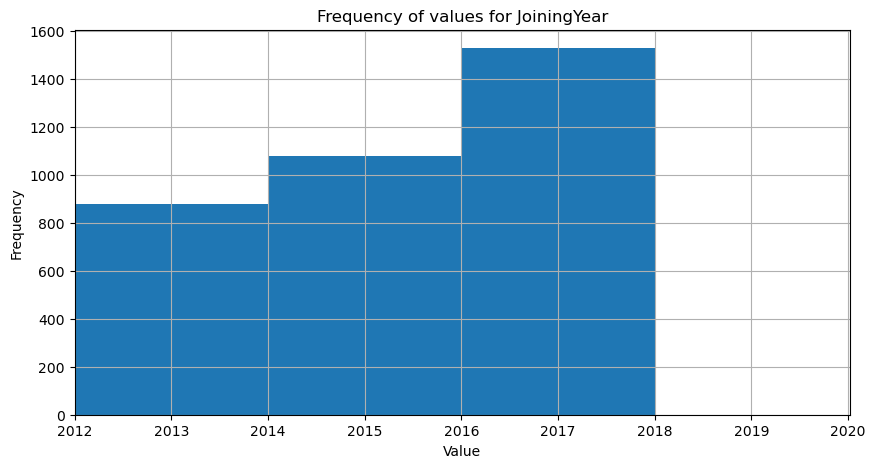

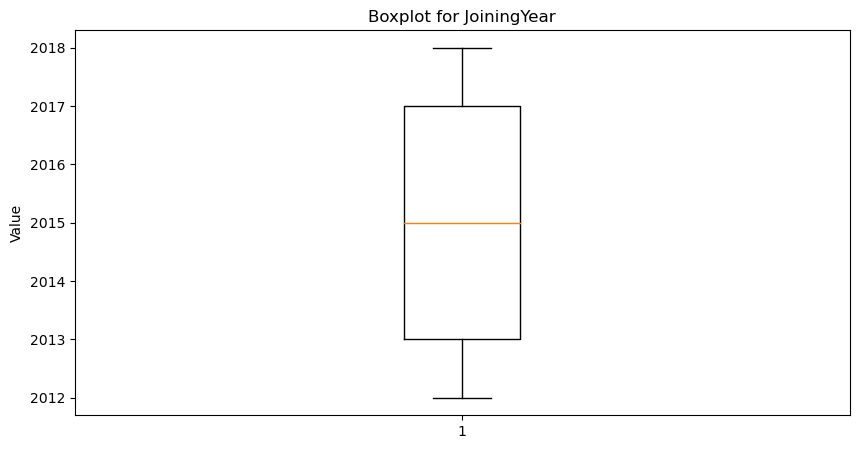

Descriptive statistics:


count    3489.000000
mean     2015.077959
std         1.868283
min      2012.000000
25%      2013.000000
50%      2015.000000
75%      2017.000000
max      2018.000000
Name: JoiningYear, dtype: float64


Analysis for column: PaymentTier


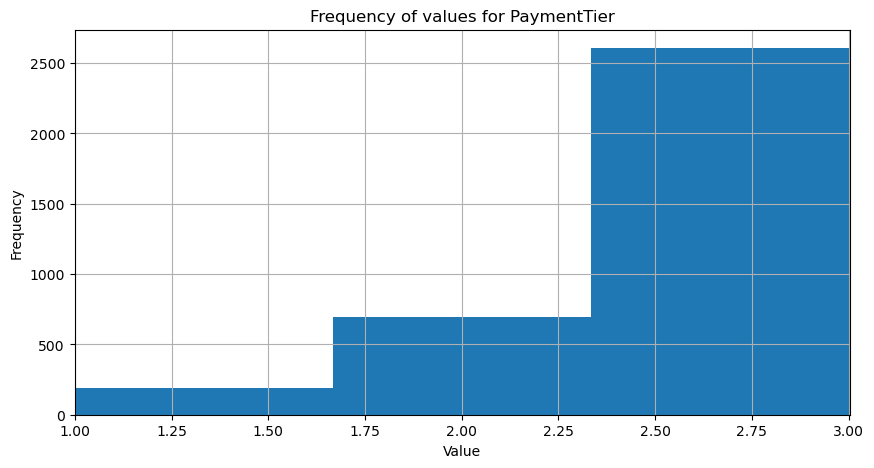

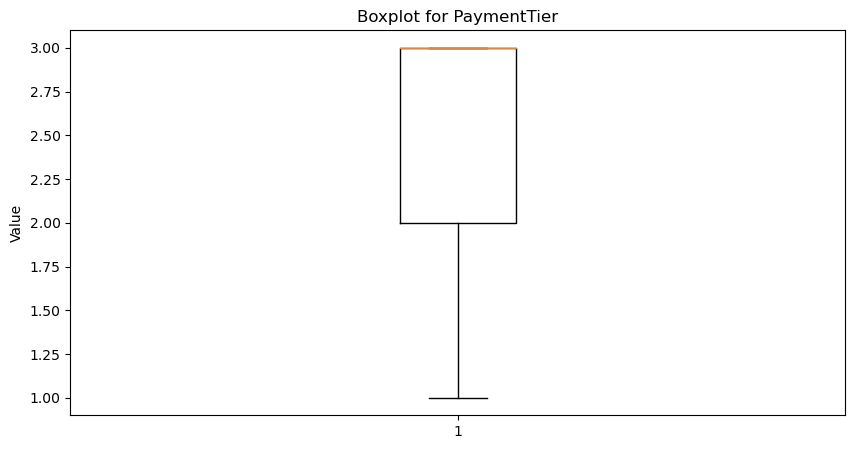

Descriptive statistics:


count    3489.000000
mean        2.692749
std         0.567322
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: PaymentTier, dtype: float64


Analysis for column: Age


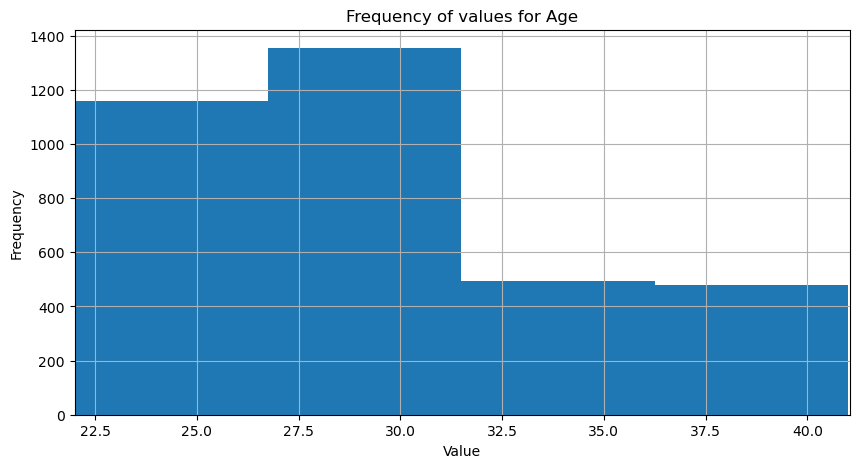

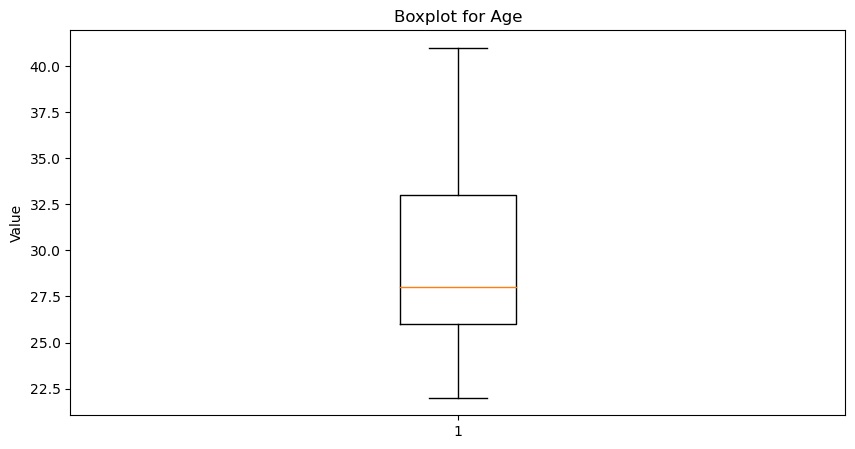

Descriptive statistics:


count    3489.000000
mean       29.439954
std         4.858304
min        22.000000
25%        26.000000
50%        28.000000
75%        33.000000
max        41.000000
Name: Age, dtype: float64


Analysis for column: ExperienceInCurrentDomain


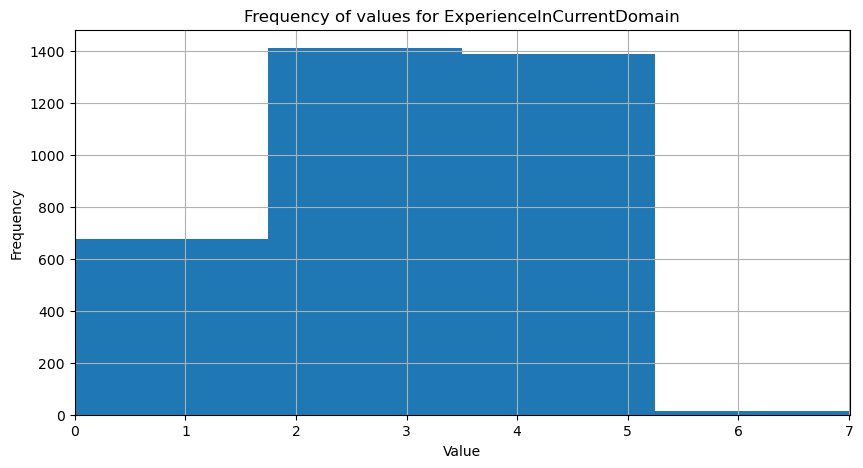

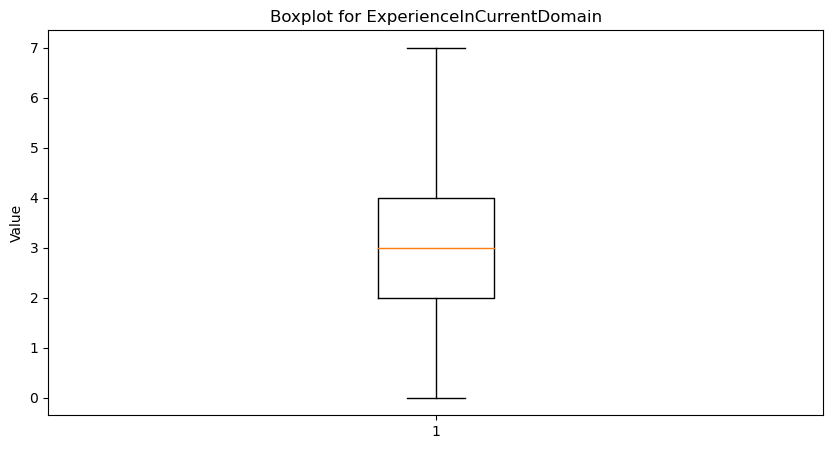

Descriptive statistics:


count    3489.000000
mean        2.907710
std         1.559622
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: ExperienceInCurrentDomain, dtype: float64


Categorical cols:

--------------------------------------------------
Analysis for column: Education


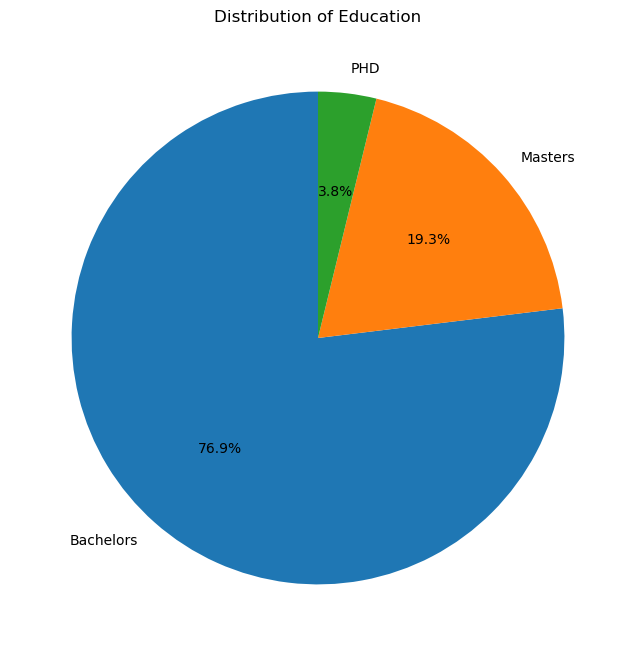

Max to min group ratio: 20.18


,Count
Education,
Bachelors,2684
Masters,672
PHD,133



--------------------------------------------------
Analysis for column: City


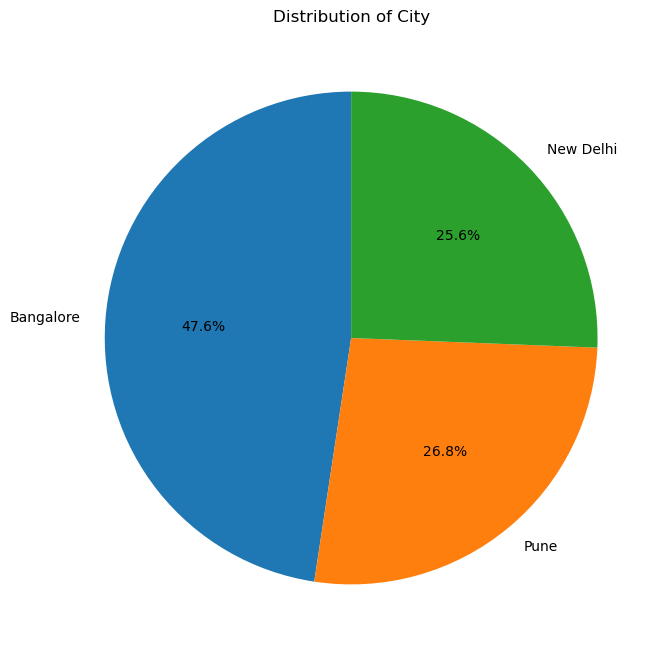

Max to min group ratio: 1.86


,Count
City,
Bangalore,1661
Pune,934
New Delhi,894



--------------------------------------------------
Analysis for column: Gender


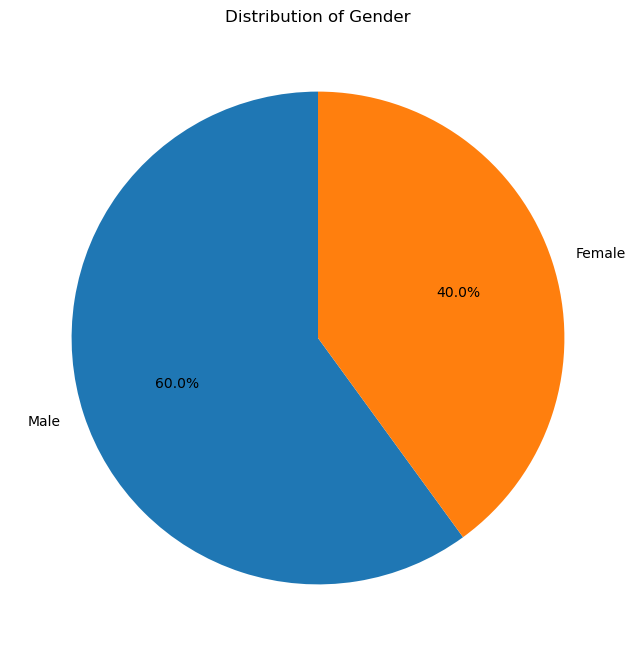

Max to min group ratio: 1.50


,Count
Gender,
Male,2094
Female,1395



--------------------------------------------------
Analysis for column: EverBenched


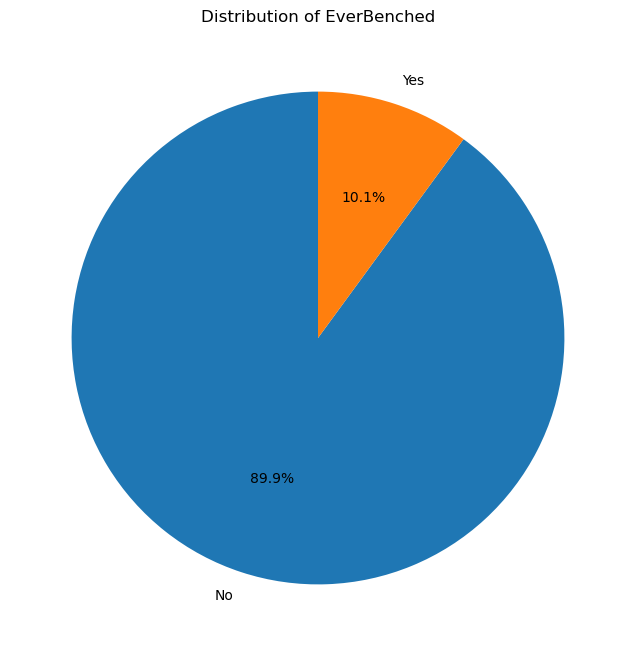

Max to min group ratio: 8.94


,Count
EverBenched,
No,3138
Yes,351



Target classes balance:


,Count
LeaveOrNot,
0,2278
1,1211


Class imbalance ratio: 1.88


In [14]:
train_df = dataframe_EDA(X_train, y_train, 1.0, 42, columns_meta, 1.001)

Numeric cols:

Analysis for column: JoiningYear


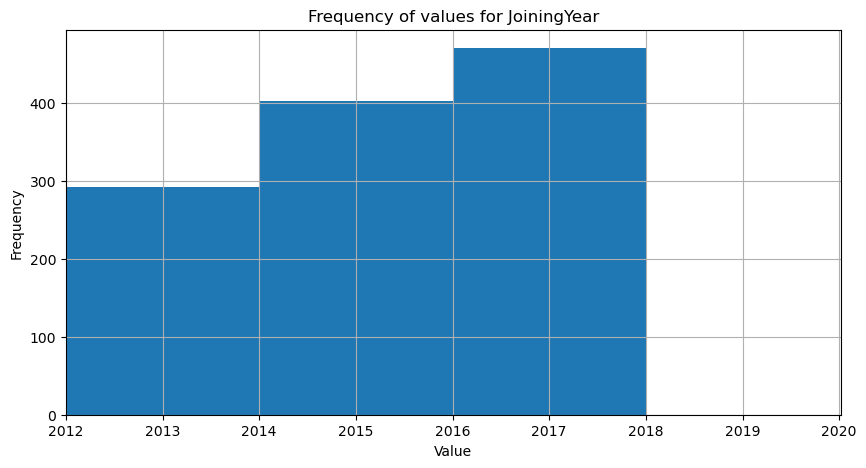

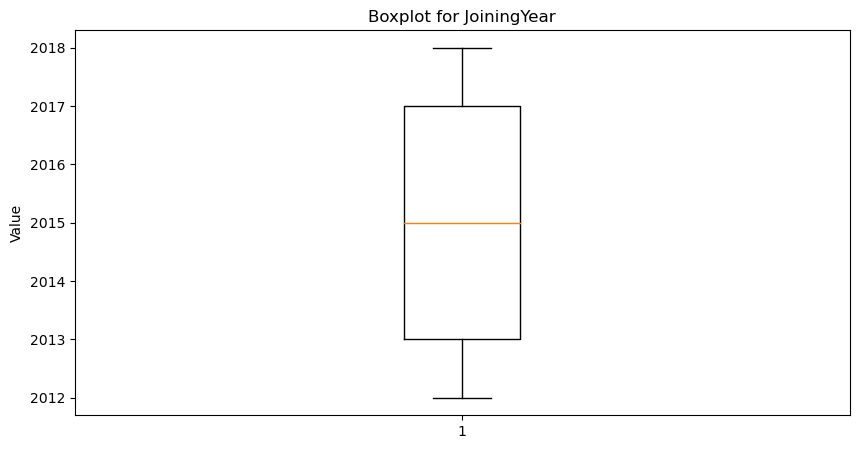

Descriptive statistics:


count    1164.000000
mean     2015.018041
std         1.848664
min      2012.000000
25%      2013.000000
50%      2015.000000
75%      2017.000000
max      2018.000000
Name: JoiningYear, dtype: float64


Analysis for column: PaymentTier


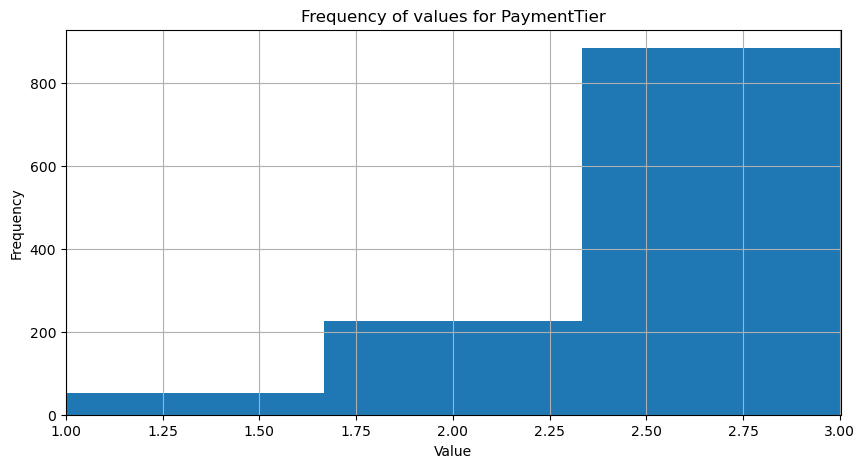

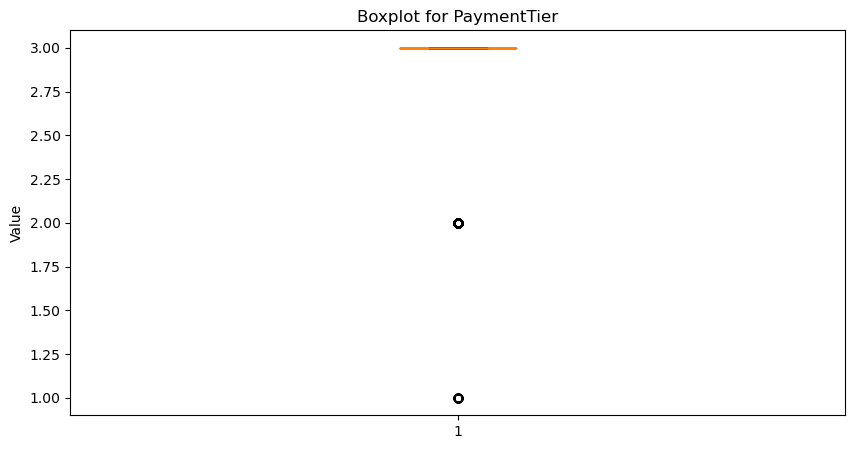

Descriptive statistics:


count    1164.000000
mean        2.714777
std         0.543314
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: PaymentTier, dtype: float64


Analysis for column: Age


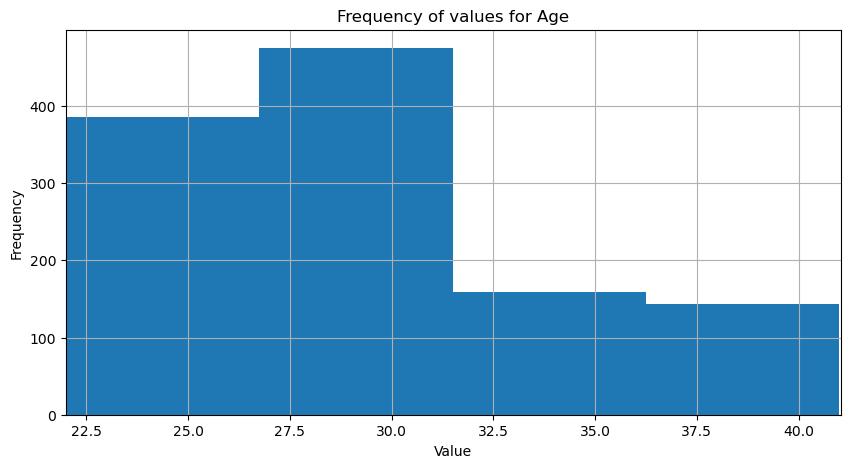

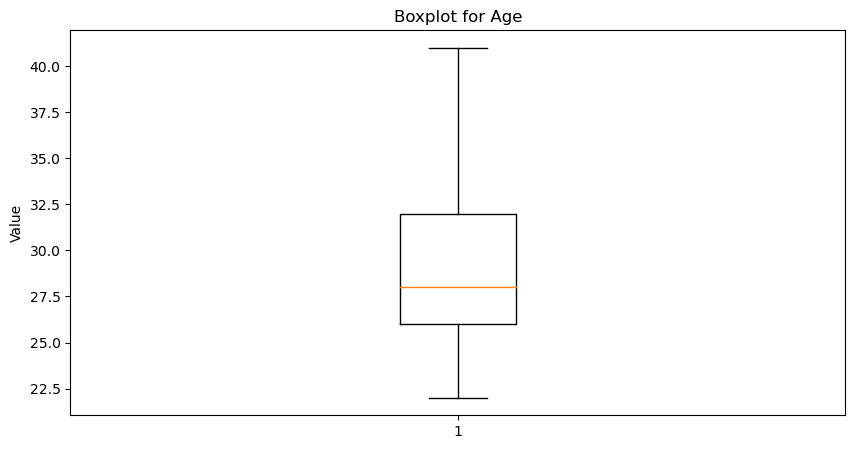

Descriptive statistics:


count    1164.000000
mean       29.253436
std         4.727505
min        22.000000
25%        26.000000
50%        28.000000
75%        32.000000
max        41.000000
Name: Age, dtype: float64


Analysis for column: ExperienceInCurrentDomain


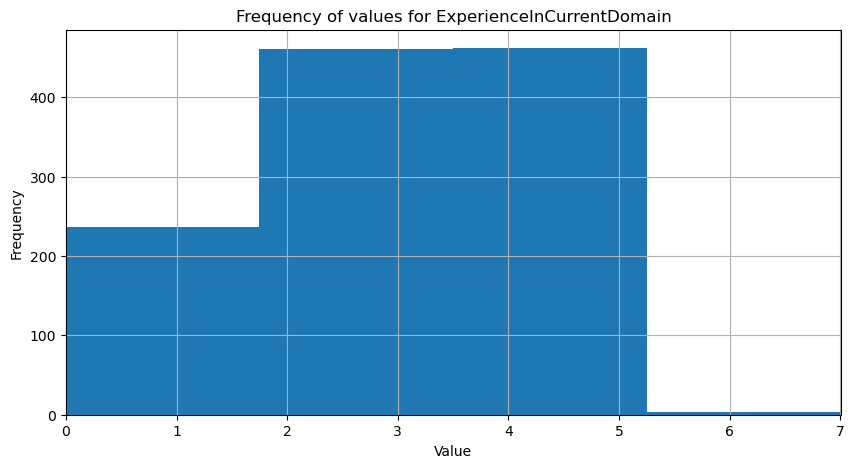

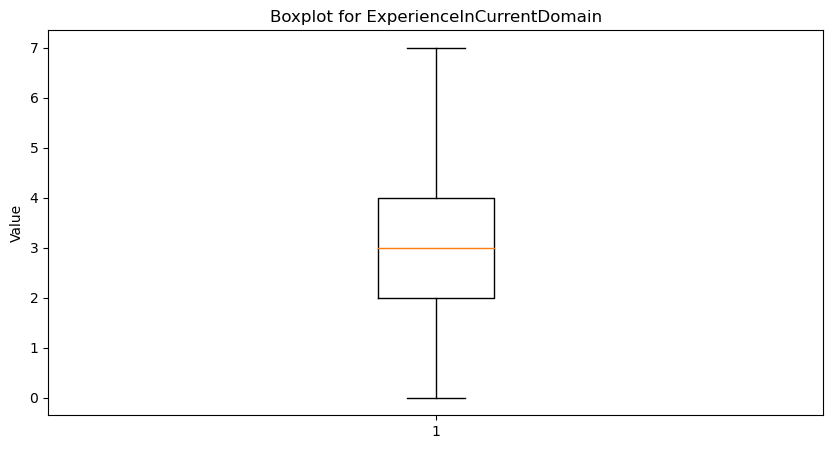

Descriptive statistics:


count    1164.000000
mean        2.899485
std         1.554745
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: ExperienceInCurrentDomain, dtype: float64


Categorical cols:

--------------------------------------------------
Analysis for column: Education


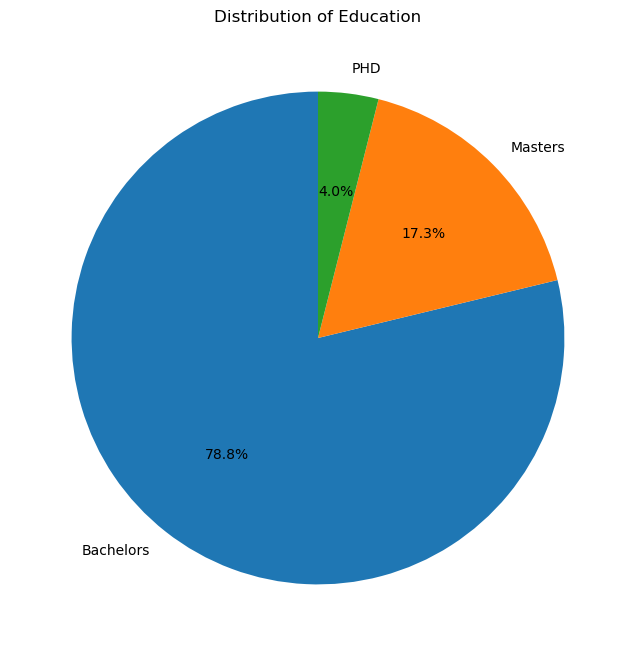

Max to min group ratio: 19.93


,Count
Education,
Bachelors,917
Masters,201
PHD,46



--------------------------------------------------
Analysis for column: City


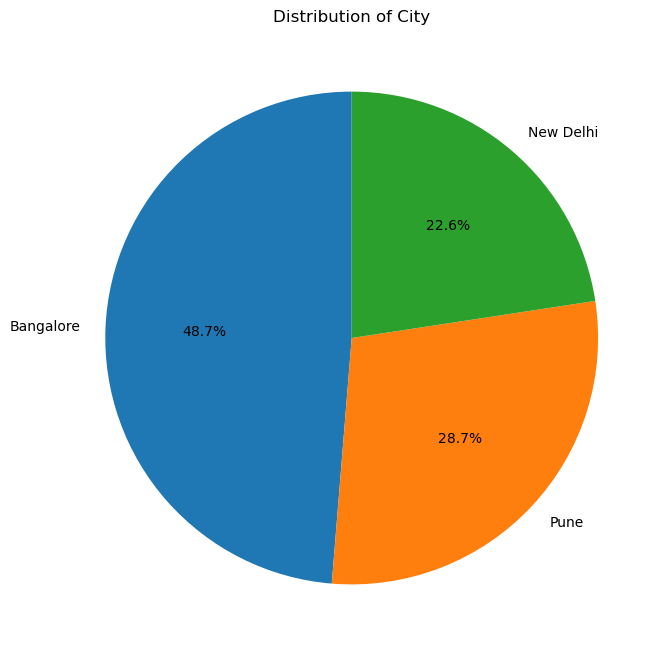

Max to min group ratio: 2.16


,Count
City,
Bangalore,567
Pune,334
New Delhi,263



--------------------------------------------------
Analysis for column: Gender


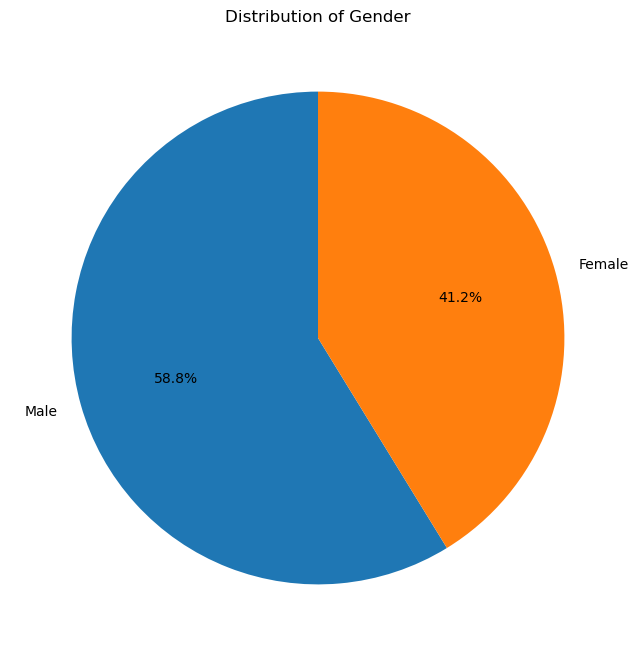

Max to min group ratio: 1.43


,Count
Gender,
Male,684
Female,480



--------------------------------------------------
Analysis for column: EverBenched


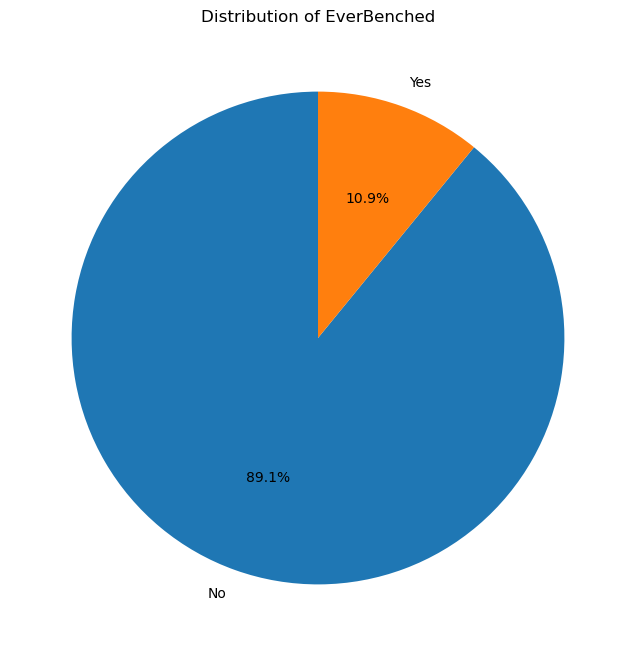

Max to min group ratio: 8.17


,Count
EverBenched,
No,1037
Yes,127



Target classes balance:


,Count
LeaveOrNot,
0,775
1,389


Class imbalance ratio: 1.99


In [15]:
test_df = dataframe_EDA(X_test, y_test, 1.0, 42, columns_meta, 1.001)

## Корреляционный анализ

In [17]:
numeric_cols = [col for col in columns_meta['numeric_cols'] if col != columns_meta['target_col']]
categorial_cols = columns_meta['categorial_cols']
numeric_cols, categorial_cols

(['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain'],
 ['Education', 'City', 'Gender', 'EverBenched'])

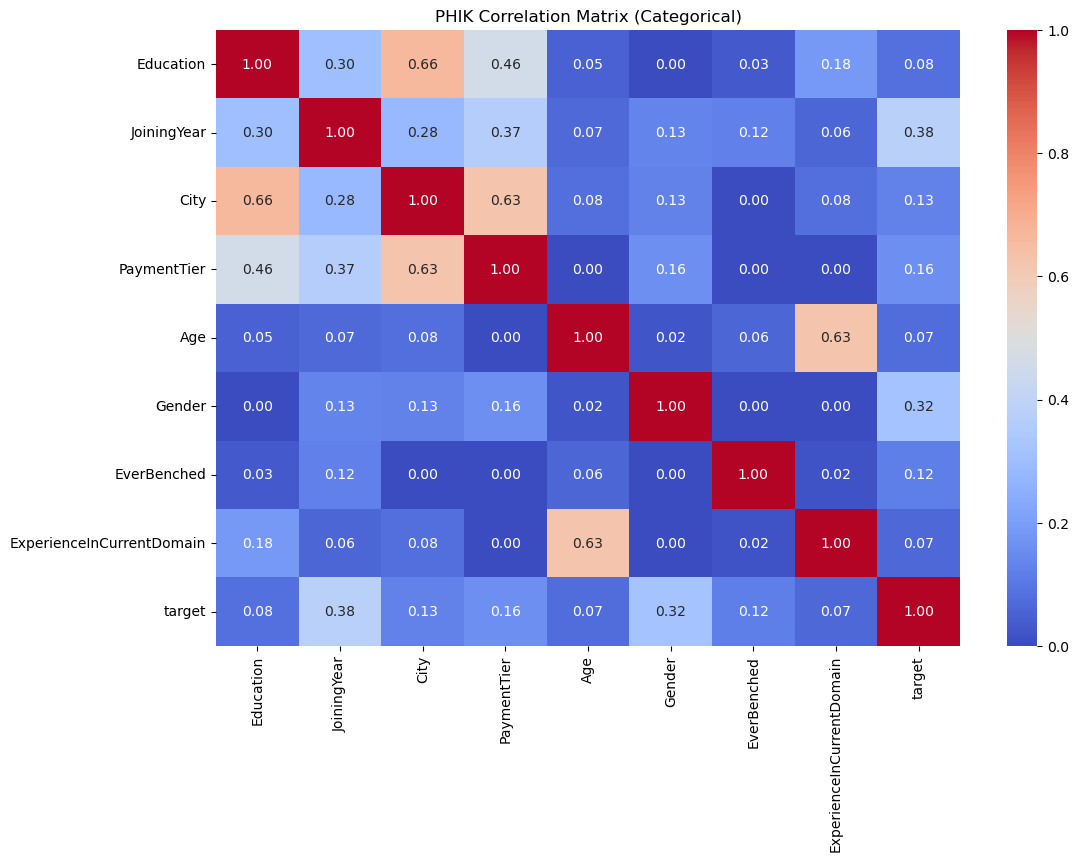

In [18]:
phik_matrix = train_df.phik_matrix(interval_cols=numeric_cols + ['target'])

fig, axes = plt.subplots(figsize=(12, 8))
sns.heatmap(phik_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
plt.title('PHIK Correlation Matrix (Categorical)')

plt.show()

## Обучение моделей

In [26]:
def train_model(train_df, test_df, model, model_name, metric, param_distributions=None, categorical_features=None, numeric_features=None):
    mlflow.set_experiment("TreeModels")

    X_train = train_df.drop(['target'], axis=1)
    y_train = train_df['target']
    X_test = test_df.drop(['target'], axis=1)
    y_test = test_df['target']
    
    with mlflow.start_run(run_name=model_name):
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ] if categorical_features else [
                ('num', StandardScaler(), numeric_features)
            ]
        )
        
        best_model, best_params = None, {}

        if isinstance(model, CatBoostClassifier):
            train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
            test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_features)

            if param_distributions:
                logger.info(f"Starting CatBoost randomized search for {model_name}")
                search = model.randomized_search(
                    param_distributions=param_distributions,
                    X=train_pool,
                    n_iter=30,
                    cv=5,
                    partition_random_seed=42,
                    calc_cv_statistics=True,
                    search_by_train_test_split=False,
                    verbose=False
                )
                best_model = model
                model.fit(train_pool)
                best_params = model.get_params()
            else:
                model.fit(train_pool)
                best_model = model
                best_params = model.get_params()

            mlflow.catboost.log_model(best_model, "model")
            y_pred = best_model.predict_proba(test_pool)[:, 1]

        else:
            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
            ])

            if param_distributions:
                logger.info(f"Starting RandomizedSearchCV for {model_name}")
                search = RandomizedSearchCV(
                    pipeline,
                    param_distributions=param_distributions,
                    n_iter=50,
                    scoring=gini_scorer,
                    cv=5,
                    verbose=0,
                    n_jobs=-1,
                    random_state=42
                )
                search.fit(X_train, y_train)
                best_model = search.best_estimator_
                best_params = search.best_params_
            else:
                pipeline.fit(X_train, y_train)
                best_model = pipeline
                best_params = {}

            model_type_str = str(type(model)).lower()
            if "lightgbm" in model_type_str:
                mlflow.lightgbm.log_model(best_model.named_steps["model"], "model")
            elif "xgboost" in model_type_str:
                mlflow.xgboost.log_model(best_model.named_steps["model"], "model")
            else:
                mlflow.sklearn.log_model(best_model, "model")

            y_pred = best_model.predict_proba(X_test)[:, 1]

        metric_res = metric(y_test, y_pred)
        mlflow.log_metric(metric.__name__, metric_res)
        mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_pred))
        mlflow.log_metric("pr_auc", average_precision_score(y_test, y_pred))

        mlflow.log_params(best_params)
        mlflow.log_text(log_stream.getvalue(), "training_log.txt")
        
        return best_model, metric_res


In [27]:
models = {
    "LightGBM": (LGBMClassifier(verbosity = -1), {
        "model__num_leaves": randint(20, 200),
        "model__learning_rate": uniform(0.005, 0.3),
        "model__n_estimators": randint(100, 300),
        "model__min_child_samples": randint(10, 100),
        "model__min_split_gain": uniform(0.0, 0.2)
    }),
    "XGBoost": (XGBClassifier(eval_metric='logloss'), {
        "model__max_depth": randint(3, 15),
        "model__learning_rate": uniform(0.005, 0.3),
        "model__n_estimators": randint(100, 300),
        "model__subsample": uniform(0.5, 0.5),
        "model__colsample_bytree": uniform(0.5, 0.5)
    }),
    "CatBoost": (CatBoostClassifier(logging_level='Silent'), {
        "depth": randint(4, 12),
        "learning_rate": uniform(0.005, 0.3),
        "iterations": randint(100, 300),
        "l2_leaf_reg": uniform(1, 10),
        "random_strength": uniform(0.1, 1.0)
    }),
    "LogisticRegression": (LogisticRegression(max_iter=1000), None)
}


In [28]:
results = {}
for name, (model, params) in models.items():
    best_model, gini = train_model(
        train_df, 
        test_df, 
        model, 
        name, 
        gini_score,
        params, 
        categorial_cols, 
        numeric_cols
    )
    results[name] = (best_model, gini)

2025/04/13 00:43:48 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2025/04/13 00:43:48 INFO mlflow.tracking._tracking_service.client: 🏃 View run LightGBM at: http://mlflow-service:5000/#/experiments/277304146179008426/runs/e5b8cdde6f4a421086c20c4ad5184f0c.
2025/04/13 00:43:48 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/277304146179008426.
2025/04/13 00:43:51 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2025/04/13 00:43:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run XGBoost at: http://mlflow-service:5000/#/experiments/277304146179008426/runs/2c157c340ff840b1b7fd1bd1d658342a.
2025/04/13 00:43:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/2

In [57]:
best_model_name = max(results.items(), key=lambda x: x[1][1])[0]
best_model, best_score = results[best_model_name]

print(f"Лучшая модель: {best_model_name} с метрикой Gini: {best_score}")

Лучшая модель: CatBoost с метрикой Gini: 0.7949349033916575


## Анализ важности

In [64]:
def explain_with_shap(model, X, model_name, save_path):
    plt.figure(figsize=(10, 6))
    
    try:
        if "CatBoost" in model_name:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X)
        elif "LightGBM" in model_name or "XGBoost" in model_name:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X)
        elif "LogisticRegression" in model_name:
            explainer = shap.LinearExplainer(model, X)
            shap_values = explainer.shap_values(X)
        
        shap.summary_plot(shap_values, X, plot_type="bar", show=False)
        plt.title(f"SHAP Feature Importance - {model_name}")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()
    except Exception as e:
        print(f"Ошибка в SHAP для {model_name}: {str(e)}")

In [65]:
def plot_feature_importances(model, X, model_name, save_path):
    plt.figure(figsize=(10, 6))
    
    try:
        if "CatBoost" in model_name:
            importances = model.get_feature_importance()
            features = X.columns
        else:
            importances = model.feature_importances_
            features = X.columns
        
        pd.Series(importances, index=features).nlargest(20).plot(kind='barh')
        plt.title(f"Feature Importances - {model_name}")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()
    except Exception as e:
        print(f"Ошибка в Feature Importances для {model_name}: {str(e)}")


In [66]:
def calculate_permutation_importance(model, X, y, model_name, save_path):
    try:
        result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
        
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance_mean': result.importances_mean,
            'importance_std': result.importances_std
        }).sort_values('importance_mean', ascending=False)
        
        plt.figure(figsize=(10, 6))
        importance_df.head(20).plot.barh(x='feature', y='importance_mean', 
                                       xerr='importance_std', legend=False)
        plt.title(f"Permutation Importance - {model_name}")
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()
        
        return importance_df
    except Exception as e:
        print(f"Ошибка в Permutation Importance для {model_name}: {str(e)}")
        return pd.DataFrame()

In [71]:
def ensure_directory_exists(filepath):
    directory = os.path.dirname(filepath)
    if directory and not os.path.exists(directory):
        os.makedirs(directory)

In [74]:
def analyze_and_log_model(best_model, X_train, y_train, name, categorial_cols=None):
    try:
        base_dir = f"analysis_results/{name}"
        shap_path = f"{base_dir}/shap_{name}.png"
        fi_path = f"{base_dir}/feature_importances_{name}.png"
        perm_path = f"{base_dir}/permutation_importance_{name}.png"
        perm_csv_path = f"{base_dir}/permutation_importance_{name}.csv"
        
        # Убеждаемся, что директории существуют
        ensure_directory_exists(shap_path)
        ensure_directory_exists(fi_path)
        ensure_directory_exists(perm_path)
        ensure_directory_exists(perm_csv_path)
        
        if "CatBoost" in name:
            train_data = Pool(data=X_train, label=y_train, cat_features=categorial_cols)
            
            explain_with_shap(best_model, train_data, name, shap_path)
            
            plot_feature_importances(best_model, X_train, name, fi_path)
            
            perm_importance = calculate_permutation_importance(
                best_model, 
                X_train, 
                y_train, 
                name, 
                perm_path
            )
            model = best_model
        
        else:
            preprocessor = best_model.named_steps['preprocessor']
            model = best_model.named_steps['model']
            X_train_transformed = preprocessor.transform(X_train)
            
            if hasattr(preprocessor, 'get_feature_names_out'):
                feature_names = preprocessor.get_feature_names_out()
                X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)
            
            explain_with_shap(model, X_train_transformed, name, shap_path)
            
            if hasattr(model, 'feature_importances_'):
                plot_feature_importances(model, X_train_transformed, name, fi_path)
            
            perm_importance = calculate_permutation_importance(
                model, X_train_transformed, y_train, name, perm_path)
        
        perm_importance.to_csv(perm_csv_path, index=False)
        
        mlflow.log_artifact(shap_path)
        mlflow.log_artifact(fi_path) if hasattr(model, 'feature_importances_') or "CatBoost" in name else None
        mlflow.log_artifact(perm_path)
        mlflow.log_artifact(perm_csv_path)
        
        return perm_importance
        
    except Exception as e:
        print(f"Ошибка при анализе модели {name}: {str(e)}")
        return None

In [75]:
X_train = train_df.drop(['target'], axis=1)
y_train = train_df['target']

for name, (best_model, gini) in results.items():
    with mlflow.start_run(run_name=f"Feature_Analysis_{name}", nested=True):
        mlflow.log_metric("gini_score", gini)
        
        if "CatBoost" in name:
            train_pool = Pool(data=X_train, label=y_train, cat_features=categorial_cols)
            analyze_and_log_model(
                best_model=best_model,
                X_train=X_train,  
                y_train=y_train,
                name=name,
                categorial_cols=categorial_cols
            )
        else:
            analyze_and_log_model(
                best_model=best_model,
                X_train=X_train,
                y_train=y_train,
                name=name
            )
        
        mlflow.set_tags({
            "model_type": name,
            "analysis": "feature_importance",
            "stage": "analysis"
        })
        
        print(f"Анализ признаков для модели {name} завершен и залогирован")

2025/04/13 01:24:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run Feature_Analysis_LightGBM at: http://mlflow-service:5000/#/experiments/277304146179008426/runs/49d8d2505f744e8eb6ba285f5b81493c.
2025/04/13 01:24:11 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/277304146179008426.


Анализ признаков для модели LightGBM завершен и залогирован


2025/04/13 01:24:12 INFO mlflow.tracking._tracking_service.client: 🏃 View run Feature_Analysis_XGBoost at: http://mlflow-service:5000/#/experiments/277304146179008426/runs/acbf9e1ae40e4180b863911bc2189719.
2025/04/13 01:24:12 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/277304146179008426.


Анализ признаков для модели XGBoost завершен и залогирован


2025/04/13 01:24:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run Feature_Analysis_CatBoost at: http://mlflow-service:5000/#/experiments/277304146179008426/runs/d046252bfacb4458b4f896ee2fb859e1.
2025/04/13 01:24:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow-service:5000/#/experiments/277304146179008426.


...

Анализ признаков для модели LogisticRegression завершен и залогирован


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>